In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("winequality-red.csv",sep=";")

In [3]:
df["target"]=df["quality"].apply(lambda x:1 if x>=7 else 0)

In [4]:
print("Before SMOTE",df["target"].value_counts())

Before SMOTE target
0    1382
1     217
Name: count, dtype: int64


In [5]:
x=df.drop(["quality","target"],axis=1)
y=df["target"]

In [6]:
smote=SMOTE(random_state=42)
x_balanced,y_balanced=smote.fit_resample(x,y)

In [7]:
x=df.drop(["quality","target"],axis=1)
y=df["target"]

In [8]:
print("After SMOTE",y_balanced.value_counts())

After SMOTE target
0    1382
1    1382
Name: count, dtype: int64


In [9]:
print("After SMOTE",y_balanced.value_counts())

After SMOTE target
0    1382
1    1382
Name: count, dtype: int64


In [10]:
x_train,x_test,y_train,y_test=train_test_split(
    x_balanced,y_balanced,test_size=0.2,random_state=42,stratify=y_balanced
)

In [11]:


model =GradientBoostingClassifier(
     
   n_estimators=100,
    learning_rate=1.0,
    max_depth=2,
    random_state=42
)

In [12]:
model.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=1.0, max_depth=2, random_state=42)

In [13]:
y_pred=model.predict(x_test)

In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       277
           1       0.91      0.95      0.93       276

    accuracy                           0.93       553
   macro avg       0.93      0.93      0.93       553
weighted avg       0.93      0.93      0.93       553



In [15]:
print(accuracy_score(y_test,y_pred))

0.9294755877034359


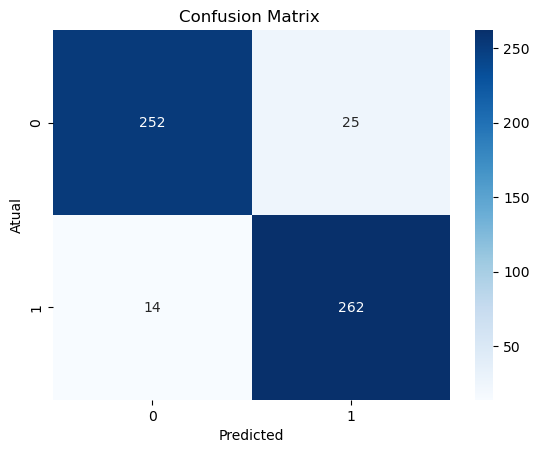

In [16]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True ,fmt="d",cmap="Blues")
plt.title("Confusion Matrix ")
plt.xlabel("Predicted")
plt.ylabel("Atual")
plt.show()


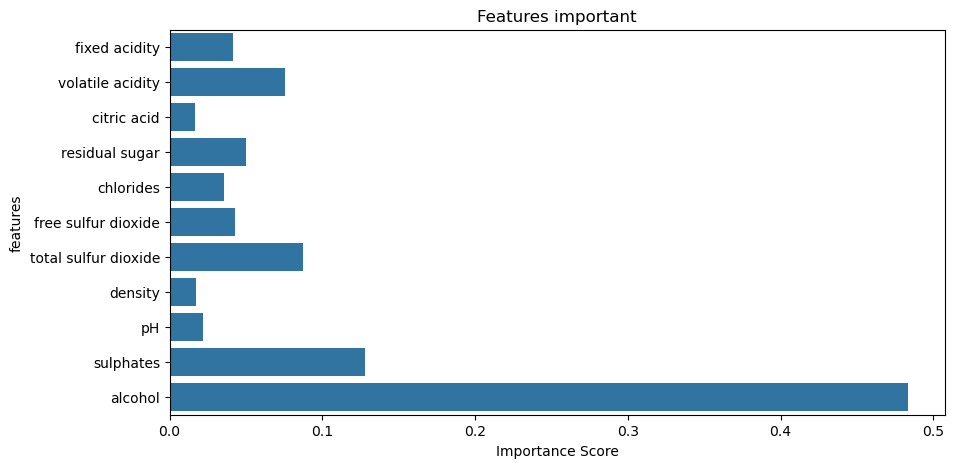

In [18]:
importances=model.feature_importances_
features=x.columns
plt.figure(figsize=(10,5))
sns.barplot(x=importances,y=features)
plt.title("Features important")
plt.xlabel("Importance Score")
plt.ylabel("features")
plt.show()
